In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import RocCurveDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
from google.colab import files
uploaded=files.upload()

Saving customer_churn_dataset-training-master.csv to customer_churn_dataset-training-master.csv


In [3]:
df=pd.read_csv("customer_churn_dataset-training-master.csv")

In [4]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [6]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [7]:
df.isnull().sum()

,0
CustomerID,1
Age,1
Gender,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Subscription Type,1
Contract Length,1
Total Spend,1


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

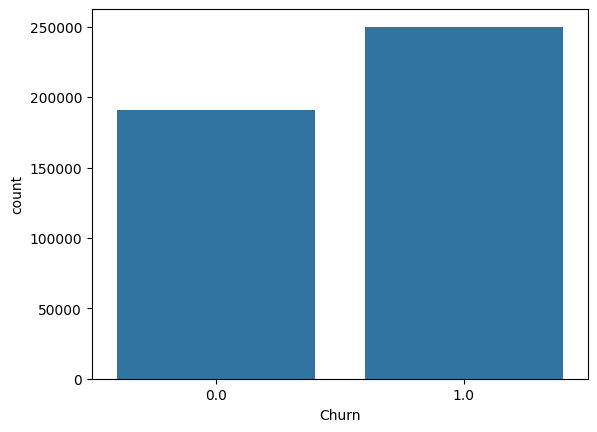

In [8]:
sns.countplot(x='Churn',data=df)
plt.show()

In [9]:
encoder=LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col]=encoder.fit_transform(df[col])

In [10]:
X=df.drop("Churn",axis=1)

y=df["Churn"]

scaler=StandardScaler()

X=scaler.fit_transform(X)

In [11]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
baseline=LogisticRegression()

baseline.fit(X_train,y_train)

baseline_pred=baseline.predict(X_test)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [13]:
df.isnull().sum()

,0
CustomerID,1
Age,1
Gender,0
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Subscription Type,0
Contract Length,0
Total Spend,1


In [ ]:
X = df.drop("Churn", axis=1)

print(X.isnull().sum())

CustomerID           1
Age                  1
Gender               0
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    0
Contract Length      0
Total Spend          1
Last Interaction     1
dtype: int64


In [14]:
print(df.isnull().sum().sum())

9


In [15]:
from sklearn.impute import SimpleImputer

X = df.drop("Churn", axis=1)
y = df["Churn"]

imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(X)

In [16]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
baseline = LogisticRegression(max_iter=1000)

baseline.fit(X_train, y_train)

ValueError: Input y contains NaN.

In [ ]:
print(df["Churn"].isnull().sum())

1


In [17]:
df[df["Churn"].isnull()]

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
199295,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,NaN,NaN,NaN


In [18]:
df = df.dropna(subset=["Churn"])

In [19]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [20]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(X)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [22]:
baseline = LogisticRegression(max_iter=1000)
baseline.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [23]:
print(df.shape)

(440832, 12)


In [24]:
baseline=LogisticRegression()

baseline.fit(X_train,y_train)

baseline_pred=baseline.predict(X_test)

In [25]:
print(accuracy_score(y_test,baseline_pred))
print(precision_score(y_test,baseline_pred))
print(recall_score(y_test,baseline_pred))
print(f1_score(y_test,baseline_pred))

0.9775312758741933
0.9817406450837888
0.9786643780935654
0.9802000979500455


In [26]:
optimized=RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

optimized.fit(X_train,y_train)

optimized_pred=optimized.predict(X_test)

In [ ]:
from sklearn.model_selection import GridSearchCV

params={
    'n_estimators':[100,200,300],
    'max_depth':[5,10,15],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}

grid=GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train,y_train)

best_model=grid.best_estimator_

pred=best_model.predict(X_test)